In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../../../data/processed/land_dataset_final_v3_noisy_2.csv')

In [4]:
df.isnull().sum()

address_subdivision    0
address_locality       0
address_line_2         0
h_id                   0
price_per_m2           0
                      ..
f_track                0
f_trunk                0
f_trunk_link           0
f_unclassified         0
f_unused               0
Length: 234, dtype: int64

In [5]:
unique_counts = df.nunique()
print(unique_counts)

address_subdivision       1
address_locality         12
address_line_2           96
h_id                    840
price_per_m2           9272
                       ... 
f_track                   2
f_trunk                   2
f_trunk_link              2
f_unclassified            2
f_unused                  1
Length: 234, dtype: int64


In [6]:
df.columns.to_list()

['address_subdivision',
 'address_locality',
 'address_line_2',
 'h_id',
 'price_per_m2',
 'land_area',
 'price',
 'longitude',
 'latitude',
 'near_Koh_Pich_in_km',
 'Koh_Pich_nearest',
 'Koh_Pich_1_2km',
 'Koh_Pich_2_3km',
 'Koh_Pich_3_5km',
 'Koh_Pich_5_10km',
 'near_Russian_Market_in_km',
 'Russian_Market_nearest',
 'Russian_Market_1_2km',
 'Russian_Market_2_3km',
 'Russian_Market_3_5km',
 'Russian_Market_5_10km',
 'near_AEON_Mall_1_in_km',
 'AEON_Mall_1_nearest',
 'AEON_Mall_1_1_2km',
 'AEON_Mall_1_2_3km',
 'AEON_Mall_1_3_5km',
 'AEON_Mall_1_5_10km',
 'near_AEON_Mall_2_in_km',
 'AEON_Mall_2_nearest',
 'AEON_Mall_2_1_2km',
 'AEON_Mall_2_2_3km',
 'AEON_Mall_2_3_5km',
 'AEON_Mall_2_5_10km',
 'near_AEON_Mall_3_in_km',
 'AEON_Mall_3_nearest',
 'AEON_Mall_3_1_2km',
 'AEON_Mall_3_2_3km',
 'AEON_Mall_3_3_5km',
 'AEON_Mall_3_5_10km',
 'near_Bassac_Lane_in_km',
 'Bassac_Lane_nearest',
 'Bassac_Lane_1_2km',
 'Bassac_Lane_2_3km',
 'Bassac_Lane_3_5km',
 'Bassac_Lane_5_10km',
 'near_Koh_Norea_in

In [7]:
# # Add mean, max, median, min of price_per_m2 for each row, grouped by h_id
# agg_stats = df.groupby('h_id')['price_per_m2'].agg(['mean', 'max', 'median', 'min'])
# agg_stats = agg_stats.rename(columns={
#     'mean': 'h_id_price_mean',
#     'max': 'h_id_price_max',
#     'median': 'h_id_price_median',
#     'min': 'h_id_price_min'
# })

# # Merge these stats back to the original dataframe
# df = df.merge(agg_stats, left_on='h_id', right_index=True)

In [8]:
df

,address_subdivision,address_locality,address_line_2,h_id,price_per_m2,land_area,price,longitude,latitude,near_Koh_Pich_in_km,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,Phnom Penh,Mean Chey,Stueng Mean Chey,8865846a91fffff,3249.773855,52.849329,1.717484e+05,104.883100,11.552932,5.751517,...,0,1,1,0,0,0,0,0,0,0
1,Phnom Penh,Chamkar Mon,Phsar Daeum Thkov,8865846acbfffff,2357.960918,179.682029,4.236832e+05,104.915003,11.528833,2.951587,...,0,0,0,0,0,0,0,0,0,0
2,Phnom Penh,Saensokh,Phnom Penh Thmei,88658468cbfffff,3466.326691,139.038859,4.819541e+05,104.886163,11.586713,6.822753,...,0,0,1,0,0,0,0,0,0,0
3,Phnom Penh,Saensokh,Phnom Penh Thmei,8865846ab1fffff,2979.374452,161.920279,4.824211e+05,104.889529,11.575790,6.075819,...,0,0,0,0,0,0,0,0,0,0
4,Phnom Penh,Doun Penh,Chakto Mukh,8865846a39fffff,5133.654419,200.964577,1.031683e+06,104.958218,11.558388,0.811035,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9267,Phnom Penh,Chraoy Chongvar,Bak Kaeng,886586a699fffff,649.765695,180.608364,1.173531e+05,104.929226,11.701893,16.053352,...,0,0,0,0,0,0,0,0,0,0
9268,Phnom Penh,Chraoy Chongvar,Preaek Ta Sek,8865846995fffff,158.350974,209.621191,3.319372e+04,104.899855,11.667508,13.149428,...,0,0,0,0,0,0,0,0,0,0
9269,Phnom Penh,Praek Pnov,Ponsang,8865846d85fffff,281.534392,133.551777,3.759942e+04,104.756877,11.633307,22.017518,...,0,0,0,0,0,0,0,0,0,0
9270,Phnom Penh,Pur SenChey,Kantaok,8865846e31fffff,511.506551,229.191548,1.172330e+05,104.785133,11.523526,16.977042,...,0,0,1,0,0,0,0,0,0,0


In [9]:
X = df.drop(columns=["price_per_m2", "price", "longitude", "latitude", "geometry", "land_area"])
y = df["price_per_m2"]

In [10]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['address_subdivision', 'address_locality', 'address_line_2', 'h_id']


In [11]:
X_original_categorical = X[categorical_cols].copy()

In [12]:
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    
    # Create mapping dictionary
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoding map for {col}: {mapping}")

# Save mappings to file (for future use)
import joblib
joblib.dump(label_encoders, '../../../data/processed/label_encoders_v2.pkl')


Encoding map for address_subdivision: {'Phnom Penh': 0}
Encoding map for address_locality: {'Chamkar Mon': 0, 'Chbar Ampov': 1, 'Chraoy Chongvar': 2, 'Dangkao': 3, 'Doun Penh': 4, 'Mean Chey': 5, 'Praek Pnov': 6, 'Prampir Meakkakra': 7, 'Pur SenChey': 8, 'Russey Keo': 9, 'Saensokh': 10, 'Tuol Kouk': 11}
Encoding map for address_line_2: {'Bak Kaeng': 0, 'Boeng Kak Ti Muoy': 1, 'Boeng Kak Ti Pir': 2, 'Boeng Keng Kang Ti Bei': 3, 'Boeng Keng Kang Ti Muoy': 4, 'Boeng Keng Kang Ti Pir': 5, 'Boeng Proluet': 6, 'Boeng Reang': 7, 'Boeng Salang': 8, 'Boeng Thum': 9, 'Boeng Trabaek': 10, 'Boeng Tumpun': 11, 'Chak Angrae Kraom': 12, 'Chak Angrae Leu': 13, 'Chakto Mukh': 14, 'Chaom Chau': 15, 'Chbar Ampov Ti Pir': 16, 'Cheung Aek': 17, 'Chey Chummeah': 18, 'Chhbar Ampov Ti Muoy': 19, 'Chrang Chamreh Ti Muoy': 20, 'Chrang Chamreh Ti Pir': 21, 'Chrouy Changvar': 22, 'Dangkao': 23, 'Kakab': 24, 'Kamboul': 25, 'Kantaok': 26, 'Kaoh Dach': 27, 'Kbal Kaoh': 28, 'Khmuonh': 29, 'Kilomaetr Lekh Prammuoy': 3

['../../../data/processed/label_encoders_v2.pkl']

In [13]:
# Remove near-constant features
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed
X_variance = selector.fit_transform(X_encoded)

# Get selected features
selected_features_variance = X_encoded.columns[selector.get_support()]
print(f"Features after variance threshold: {list(selected_features_variance)}")
print(f"Removed features: {list(set(X_encoded.columns) - set(selected_features_variance))}")

# Update dataset
X_filtered = pd.DataFrame(X_variance, columns=selected_features_variance)


Features after variance threshold: ['address_locality', 'address_line_2', 'h_id', 'near_Koh_Pich_in_km', 'Koh_Pich_1_2km', 'Koh_Pich_2_3km', 'Koh_Pich_3_5km', 'Koh_Pich_5_10km', 'near_Russian_Market_in_km', 'Russian_Market_nearest', 'Russian_Market_1_2km', 'Russian_Market_2_3km', 'Russian_Market_3_5km', 'Russian_Market_5_10km', 'near_AEON_Mall_1_in_km', 'AEON_Mall_1_nearest', 'AEON_Mall_1_1_2km', 'AEON_Mall_1_2_3km', 'AEON_Mall_1_3_5km', 'AEON_Mall_1_5_10km', 'near_AEON_Mall_2_in_km', 'AEON_Mall_2_1_2km', 'AEON_Mall_2_2_3km', 'AEON_Mall_2_3_5km', 'AEON_Mall_2_5_10km', 'near_AEON_Mall_3_in_km', 'AEON_Mall_3_2_3km', 'AEON_Mall_3_3_5km', 'AEON_Mall_3_5_10km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_nearest', 'Bassac_Lane_1_2km', 'Bassac_Lane_2_3km', 'Bassac_Lane_3_5km', 'Bassac_Lane_5_10km', 'near_Koh_Norea_in_km', 'Koh_Norea_1_2km', 'Koh_Norea_2_3km', 'Koh_Norea_3_5km', 'Koh_Norea_5_10km', 'near_Camko_City_in_km', 'Camko_City_nearest', 'Camko_City_1_2km', 'Camko_City_2_3km', 'Camko_City_3

Removed correlated features: ['near_Koh_Pich_in_km', 'near_Russian_Market_in_km', 'near_AEON_Mall_1_in_km', 'near_AEON_Mall_2_in_km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_5_10km', 'near_Koh_Norea_in_km', 'near_Camko_City_in_km', 'near_Olympic_Stadium_in_km', 'near_Phsar_Tmey_in_km', 'Phsar_Tmey_5_10km', 'near_Boeng_Keng_Kang_1_in_km', 'near_Wat_Phnom_in_km', 'Wat_Phnom_5_10km', 'near_Chroy_Changvar_Bridge_in_km', 'near_Vattanac_Tower_in_km', 'Vattanac_Tower_5_10km', 'near_Royal_Palace_in_km', 'Royal_Palace_5_10km', 'near_Sisowath_Riverside_Park_in_km', 'Sisowath_Riverside_Park_3_5km', 'Sisowath_Riverside_Park_5_10km', 'near_Phsar_Chas_in_km', 'Phsar_Chas_3_5km', 'Phsar_Chas_5_10km', 'near_Phsar_kandal_in_km', 'Phsar_kandal_1_2km', 'Phsar_kandal_3_5km', 'n_cafe_5km', 'n_cafe_in_1km', 'n_cafe_in_1km_to_2km', 'n_cafe_in_2km_to_3km', 'n_cafe_in_3km_to_5km', 'n_gas_station_5km', 'n_gas_station_in_1km_to_2km', 'n_gas_station_in_2km_to_3km', 'n_gas_station_in_3km_to_5km', 'n_hospital_5km', 

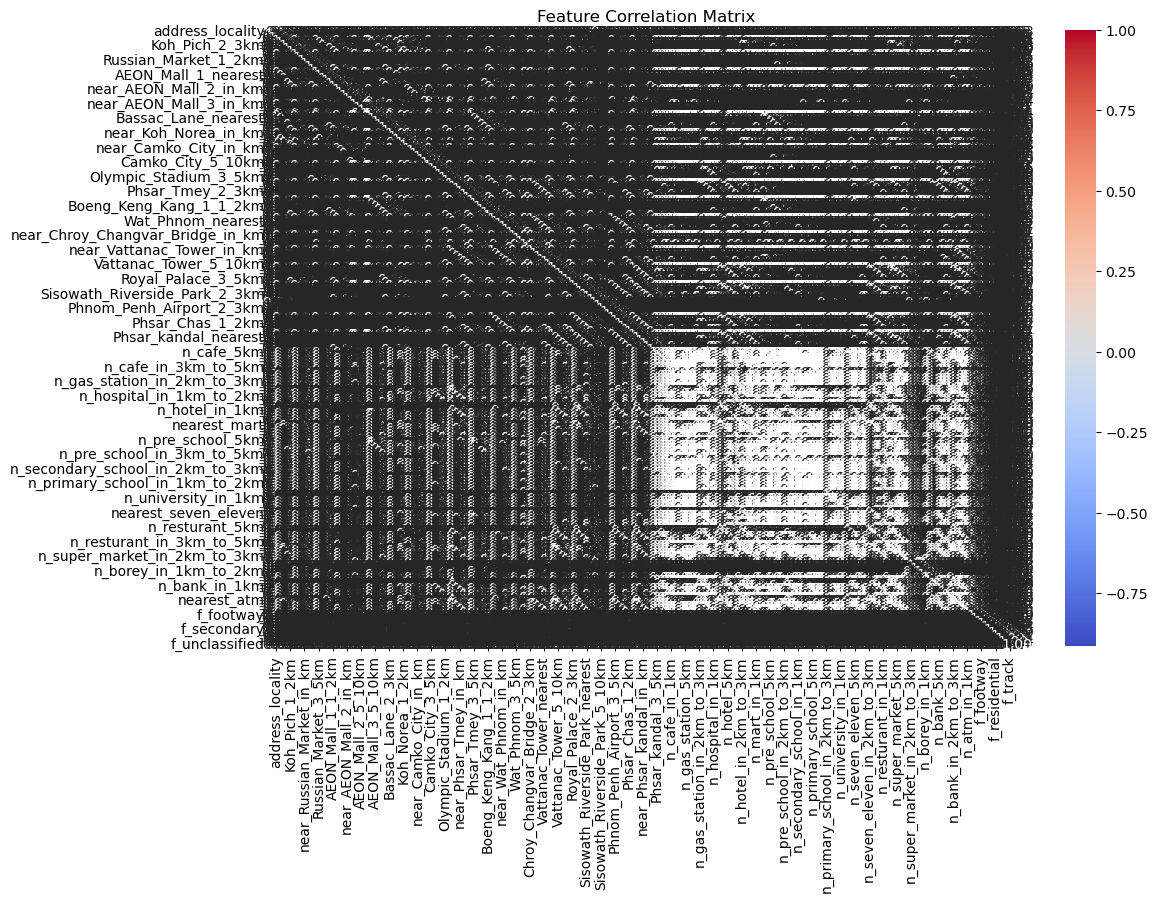

In [14]:
# Calculate correlation matrix
corr_matrix = X_filtered.corr().abs()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Find highly correlated features (≥0.85)
high_corr = (corr_matrix.mask(mask) >= 0.85).any()
features_to_remove = high_corr[high_corr].index.tolist()

# Remove correlated features
X_uncorr = X_filtered.drop(columns=features_to_remove)
print(f"Removed correlated features: {features_to_remove}")
print(f"Features after correlation filter: {X_uncorr.columns.tolist()}")

# Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(X_filtered.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_uncorr, y, test_size=0.2, random_state=42
)


d:\anaconda\envs\env_v3.10\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.131e+09, tolerance: 2.673e+06
  model = cd_fast.enet_coordinate_descent(


Lasso selected features: ['address_locality', 'address_line_2', 'h_id', 'Koh_Pich_1_2km', 'Koh_Pich_2_3km', 'Koh_Pich_3_5km', 'Koh_Pich_5_10km', 'Russian_Market_nearest', 'Russian_Market_1_2km', 'Russian_Market_2_3km', 'Russian_Market_3_5km', 'Russian_Market_5_10km', 'AEON_Mall_1_nearest', 'AEON_Mall_1_1_2km', 'AEON_Mall_1_2_3km', 'AEON_Mall_1_3_5km', 'AEON_Mall_1_5_10km', 'AEON_Mall_2_1_2km', 'AEON_Mall_2_2_3km', 'AEON_Mall_2_3_5km', 'AEON_Mall_2_5_10km', 'near_AEON_Mall_3_in_km', 'AEON_Mall_3_2_3km', 'AEON_Mall_3_3_5km', 'AEON_Mall_3_5_10km', 'Bassac_Lane_nearest', 'Bassac_Lane_1_2km', 'Bassac_Lane_2_3km', 'Bassac_Lane_3_5km', 'Koh_Norea_1_2km', 'Koh_Norea_2_3km', 'Koh_Norea_3_5km', 'Koh_Norea_5_10km', 'Camko_City_nearest', 'Camko_City_1_2km', 'Camko_City_2_3km', 'Camko_City_3_5km', 'Camko_City_5_10km', 'Olympic_Stadium_nearest', 'Olympic_Stadium_1_2km', 'Olympic_Stadium_2_3km', 'Olympic_Stadium_3_5km', 'Olympic_Stadium_5_10km', 'Phsar_Tmey_nearest', 'Phsar_Tmey_1_2km', 'Phsar_Tmey_2

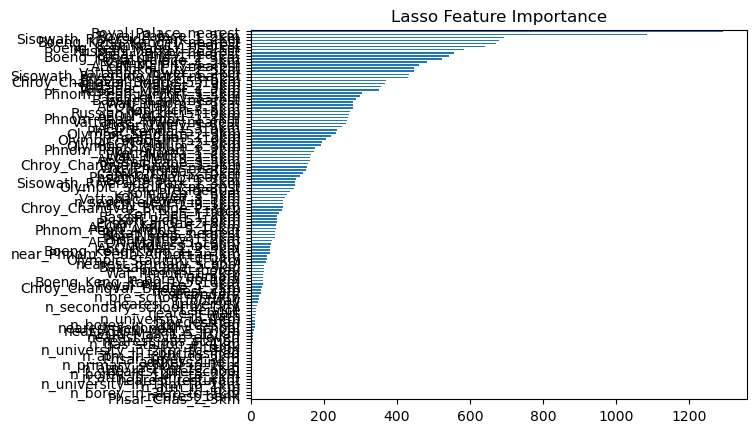

In [16]:
# Lasso feature selection
lasso = Lasso(alpha=0.01)  # Adjust alpha for regularization strength
lasso.fit(X_train, y_train)

# Get feature importance
lasso_importance = pd.Series(np.abs(lasso.coef_), index=X_uncorr.columns)
lasso_features = lasso_importance[lasso_importance > 0].index.tolist()

print("Lasso selected features:", lasso_features)
lasso_importance.sort_values().plot(kind='barh')
plt.title('Lasso Feature Importance')
plt.show()

Random Forest top features: ['n_university_in_2km_to_3km', 'n_atm_in_1km', 'address_line_2', 'n_atm_in_3km_to_5km', 'address_locality', 'near_Phnom_Penh_Airport_in_km', 'near_AEON_Mall_3_in_km', 'h_id', 'n_atm_in_1km_to_2km', 'n_atm_in_2km_to_3km']


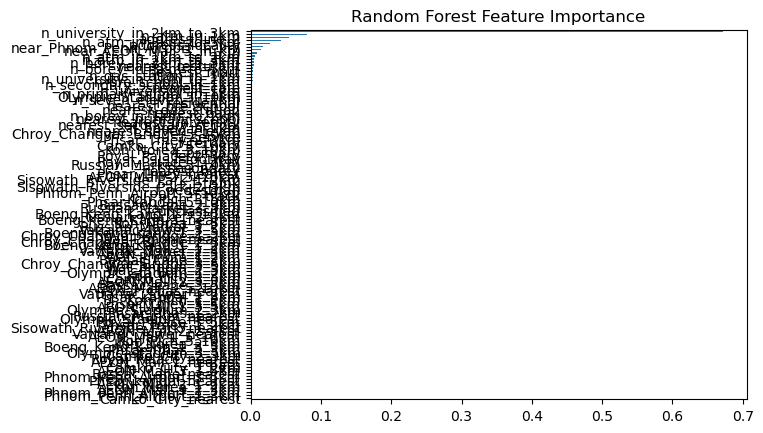

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
rf_importance = pd.Series(rf.feature_importances_, index=X_uncorr.columns)
rf_features = rf_importance.nlargest(10).index.tolist()  # Top 10 features

print("Random Forest top features:", rf_features)
rf_importance.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.show()

Permutation Importance:
                         feature  importance       std
0     n_university_in_2km_to_3km    0.648370  0.026313
3            n_atm_in_3km_to_5km    0.124794  0.004277
2                 address_line_2    0.096568  0.006154
1                   n_atm_in_1km    0.073465  0.004902
4               address_locality    0.054024  0.003993
5  near_Phnom_Penh_Airport_in_km    0.039737  0.002509
9            n_atm_in_2km_to_3km    0.016943  0.001628
6         near_AEON_Mall_3_in_km    0.009891  0.001276
7                           h_id    0.009846  0.002256
8            n_atm_in_1km_to_2km    0.002570  0.001824


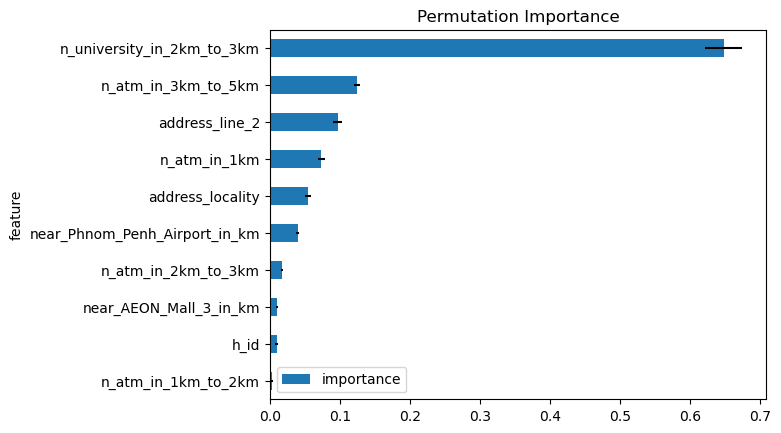

In [18]:
# Train final model (using Random Forest as example)
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train[rf_features], y_train)  # Using top RF features

# Calculate permutation importance
perm_importance = permutation_importance(
    final_model,
    X_test[rf_features],
    y_test,
    n_repeats=10,
    random_state=42
)

# Organize results
perm_df = pd.DataFrame({
    'feature': rf_features,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("Permutation Importance:")
print(perm_df)
# Visualization
perm_df.sort_values('importance').plot(
    x='feature', 
    y='importance', 
    kind='barh', 
    xerr='std',
    title='Permutation Importance'
)
plt.show()

In [19]:
# Combine selection results
selected_features = sorted(set(rf_features))
print("Final selected features:", selected_features)

Final selected features: ['address_line_2', 'address_locality', 'h_id', 'n_atm_in_1km', 'n_atm_in_1km_to_2km', 'n_atm_in_2km_to_3km', 'n_atm_in_3km_to_5km', 'n_university_in_2km_to_3km', 'near_AEON_Mall_3_in_km', 'near_Phnom_Penh_Airport_in_km']


In [20]:
# # Select only top impactful features
# final_features = [
#     'median_price_per_m2',        # Dominant price indicator
#     'address_locality',      # ATM density in mid-range
#     'n_atm_in_3km_to_5km'
# ]

# # Create final dataset
# final_X = X_uncorr[final_features]
# final_df = pd.concat([final_X, y], axis=1)

In [21]:
# # Train/test split with selected features
# X_train, X_test, y_train, y_test = train_test_split(
#     final_X, y, test_size=0.2, random_state=42
# )

# # Verify feature correlations
# plt.figure(figsize=(8, 6))
# sns.heatmap(final_X.corr(), annot=True, cmap='coolwarm')
# plt.title('Final Feature Correlation')
# plt.show()

In [22]:
final_X = X_uncorr[selected_features]
final_df = pd.concat([final_X, y], axis=1)
final_df.to_csv('../../../data/preprocessed/selected_features_dataset.csv', index=False)

In [23]:
final_df

,address_line_2,address_locality,h_id,n_atm_in_1km,n_atm_in_1km_to_2km,n_atm_in_2km_to_3km,n_atm_in_3km_to_5km,n_university_in_2km_to_3km,near_AEON_Mall_3_in_km,near_Phnom_Penh_Airport_in_km,price_per_m2
0,78.0,5.0,450.0,10.0,25.0,50.0,497.0,47.0,8.085684,3.942955,3249.773855
1,48.0,0.0,476.0,10.0,30.0,75.0,510.0,10.0,3.893582,7.980455,2357.960918
2,45.0,10.0,351.0,10.0,30.0,72.0,502.0,40.0,11.097599,6.130610,3466.326691
3,45.0,10.0,464.0,10.0,65.0,127.0,558.0,18.0,10.042650,5.951667,2979.374452
4,14.0,4.0,427.0,0.0,0.0,35.0,524.0,3.0,9.083886,13.113004,5133.654419
...,...,...,...,...,...,...,...,...,...,...,...
9267,0.0,2.0,822.0,0.0,0.0,0.0,0.0,0.0,24.022597,18.944682,649.765695
9268,66.0,2.0,378.0,0.0,0.0,0.0,0.0,0.0,20.117714,13.898293,158.350974
9269,59.0,6.0,596.0,0.0,0.0,0.0,0.0,0.0,23.077154,12.113578,281.534392
9270,26.0,8.0,653.0,0.0,0.0,0.0,0.0,0.0,13.941815,6.074774,511.506551


In [24]:
# Identify which categorical features are in the selected features
selected_categorical = [col for col in selected_features if col in categorical_cols]
selected_numerical = [col for col in selected_features if col not in categorical_cols]

print("Selected categorical features for encoding:", selected_categorical)
print("Selected numerical features:", selected_numerical)

# Save the selected label encoders (only for categorical features that were selected)
selected_label_encoders = {col: label_encoders[col] for col in selected_categorical}
joblib.dump(selected_label_encoders, '../../../data/processed/label_encoders_selected.pkl')

# Create label-encoded version of final dataset
X_label_encoded = X_uncorr[selected_features].copy()

# Create one-hot encoded version
if selected_categorical:
    # Initialize OneHotEncoder
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    # Fit and transform on selected categorical features
    X_ohe = ohe.fit_transform(X_original_categorical[selected_categorical])
    
    # Get feature names
    ohe_feature_names = ohe.get_feature_names_out(selected_categorical)
    
    # Create DataFrame
    X_ohe_df = pd.DataFrame(X_ohe, columns=ohe_feature_names)
    
    # Save one-hot encoder
    joblib.dump(ohe, '../../../data/preprocessed/onehot_encoder.pkl')
    
    # Combine with numerical features
    X_onehot = pd.concat([X[selected_numerical].reset_index(drop=True), X_ohe_df], axis=1)
else:
    X_onehot = X[selected_numerical].copy()

# Save both versions of the dataset
# Label-encoded version
final_df_label = pd.concat([X_label_encoded, y], axis=1)
final_df_label.to_csv('../../../data/preprocessed/selected_features_label_encoded_v1.csv', index=False)

# One-hot encoded version
final_df_onehot = pd.concat([X_onehot, y.reset_index(drop=True)], axis=1)
final_df_onehot.to_csv('../../../data/preprocessed/selected_features_onehot_encoded_v1.csv', index=False)

print("Datasets saved successfully:")
print(f"- Label encoded: {final_df_label.shape}")
print(f"- One-hot encoded: {final_df_onehot.shape}")

# Print encoding information
for col in selected_categorical:
    le = selected_label_encoders[col]
    print(f"\nEncoding for {col}:")
    print(f"Number of categories: {len(le.classes_)}")
    print("Category mapping:")
    for i, class_ in enumerate(le.classes_):
        print(f"  {class_}: {i}")

Selected categorical features for encoding: ['address_line_2', 'address_locality', 'h_id']
Selected numerical features: ['n_atm_in_1km', 'n_atm_in_1km_to_2km', 'n_atm_in_2km_to_3km', 'n_atm_in_3km_to_5km', 'n_university_in_2km_to_3km', 'near_AEON_Mall_3_in_km', 'near_Phnom_Penh_Airport_in_km']
Datasets saved successfully:
- Label encoded: (9272, 11)
- One-hot encoded: (9272, 956)

Encoding for address_line_2:
Number of categories: 96
Category mapping:
  Bak Kaeng: 0
  Boeng Kak Ti Muoy: 1
  Boeng Kak Ti Pir: 2
  Boeng Keng Kang Ti Bei: 3
  Boeng Keng Kang Ti Muoy: 4
  Boeng Keng Kang Ti Pir: 5
  Boeng Proluet: 6
  Boeng Reang: 7
  Boeng Salang: 8
  Boeng Thum: 9
  Boeng Trabaek: 10
  Boeng Tumpun: 11
  Chak Angrae Kraom: 12
  Chak Angrae Leu: 13
  Chakto Mukh: 14
  Chaom Chau: 15
  Chbar Ampov Ti Pir: 16
  Cheung Aek: 17
  Chey Chummeah: 18
  Chhbar Ampov Ti Muoy: 19
  Chrang Chamreh Ti Muoy: 20
  Chrang Chamreh Ti Pir: 21
  Chrouy Changvar: 22
  Dangkao: 23
  Kakab: 24
  Kamboul: 25
 